In [1]:
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch

from langchain.agents import create_agent
from langchain_core.messages.ai import AIMessage

from app.config.settings import settings

In [2]:
system_prompt = "You are a financial assistant. You can provide information about stocks, market trends, and financial news."

In [79]:
llm = ChatGroq(model=settings.ALLOWED_MODEL_NAMES[1])

tools = [TavilySearch(max_results=2, stream=True)]

agent = create_agent(model=llm,
                    tools=tools,
                    system_prompt=system_prompt
                    )

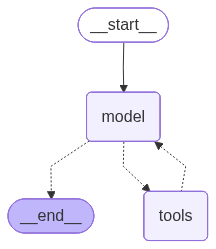

In [4]:
agent

In [5]:
state = {"messages": "what are the top 5 stocks today?"}

In [6]:
response = agent.invoke(state)
response

{'messages': [HumanMessage(content='what are the top 5 stocks today?', additional_kwargs={}, response_metadata={}, id='1cf391fb-ab2f-4d06-a9ca-a4033af53909'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jqy8d36g2', 'function': {'arguments': '{"query":"top 5 stocks today","time_range":"day","topic":"finance"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 1711, 'total_tokens': 1744, 'completion_time': 0.090473058, 'completion_tokens_details': None, 'prompt_time': 0.109024133, 'prompt_tokens_details': None, 'queue_time': 0.341951804, 'total_time': 0.199497191}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebf9b-6492-7f52-8a8a-ec9f73cd565d-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'top 5 stocks today', 'time_range': '

In [8]:
async for event in agent.astream_events(state, version="v2"):
    print(event)
        

{'event': 'on_chain_start', 'data': {'input': {'messages': 'what are the top 5 stocks today?'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ebf9c-0049-71f0-ad59-a44491737a91', 'metadata': {'ls_integration': 'langchain_create_agent'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='what are the top 5 stocks today?', additional_kwargs={}, response_metadata={}, id='98ce2b7b-fd36-4535-92b7-6ac38164cc65')]}}, 'name': 'model', 'tags': ['graph:step:1'], 'run_id': '019ebf9c-004b-7590-a8b8-89ab63c9de95', 'metadata': {'ls_integration': 'langchain_create_agent', 'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model'), 'langgraph_checkpoint_ns': 'model:cd80c0b9-72eb-613c-de8c-7c5a87a950e6'}, 'parent_ids': ['019ebf9c-0049-71f0-ad59-a44491737a91']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[SystemMessage(content='You are a financial assistant

In [7]:
await tools[0].ainvoke("What are the top 5 stocks today?")

{'query': 'What are the top 5 stocks today?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://finance.yahoo.com/markets/stocks/trending',
   'title': 'Top Trending Stocks: US stocks with the highest interest today',
   'content': 'Trending Stocks Today ; AMKR. Amkor Technology, Inc. ; NLY. Annaly Capital Management, Inc. ; SRXH. SRx Health Solutions Inc. ; RIVN. Rivian Automotive, Inc.',
   'score': 0.76659125,
   'raw_content': None},
  {'url': 'https://www.zacks.com/featured-articles/101/best-stocks-to-buy-now',
   'title': 'Best Stocks to Buy Now for June 2026 - Zacks Investment Research',
   'content': '5 Best Stocks to Buy Today ; Hilton Grand Vacations ( HGV Quick Quote HGV) · 22.86%, 10.01 ; Marathon Petroleum ( MPC Quick Quote MPC) · 10.62%, 8.40',
   'score': 0.7460839,
   'raw_content': None}],
 'response_time': 0.72,
 'request_id': 'ecadfa02-2028-48f0-9d74-6b0ba8f4cb71'}

In [9]:
def serialise_ai_message_chunk(chunk):
    if (isinstance(chunk, AIMessage)):
        return chunk.content
    else:
        raise TypeError(
            f"Object of type {type(chunk).__name__} is not correctly formatter for serialisation"
        )

In [104]:
from typing import Optional
from uuid import uuid4
import json

def sse(data: dict) -> str:
    return f"data: {json.dumps(data)}\n\n"


async def generate_agent_responses(message: str, checkpointer_id: Optional[str]):

    is_new_conversation = checkpointer_id is None

    if is_new_conversation:

        new_checkpointer_id = str(uuid4())

        config = {
            "configurable": {
                "thread_id": new_checkpointer_id,
            }
        }

        events = agent.astream_events(state, version="v2", config=config)

        yield sse({"type": "checkpoint", "checkpoint_id": new_checkpointer_id})
    
    else:

        config = {
            "configurable": {
                "thread_id": checkpointer_id,
            }
        }

        events = agent.astream_events(state, version="v2", config=config)

    async for event in events:
        event_type = event["event"]

        if event_type == "on_chat_model_stream":
            chunk_content = serialise_ai_message_chunk(event["data"]["chunk"])

            # Escape single quotes and \n for safe transmission
            safe_chunk_content = chunk_content.replace("'", "\\'").replace("\n", "\\n")

            yield sse({"type": "content", "content": safe_chunk_content})
        
        elif event_type == "on_chat_model_end":
            # check if there are any tool calls
            tool_calls = event["data"]["output"].additional_kwargs.get("tool_calls", []) if "tool_calls" in event["data"]["output"].additional_kwargs else []


            search_calls = [call for call in tool_calls if call["function"]["name"] == "tavily_search"]

            if search_calls:
                search_query = json.loads(search_calls[0]["function"]["arguments"]).get("query", "")

                safe_search_query = search_query.replace("'", "\\'").replace("\n", "\\n")

                yield sse({"type": "search_start", "query": safe_search_query})
        
        elif event_type == "on_tool_end" and event["name"] == "tavily_search":
            output = json.loads(event["data"]["output"].content)["results"]

            if isinstance(output, list):
                urls = []
                for item in output:
                    if isinstance(item, dict) and "url" in item:
                        urls.append(item["url"])
            

                yield sse({"type": "search_results", "urls": urls})
    
    yield sse({"type": "end"})


In [105]:
import asyncio

async def test_stream(message, checkpoint_id=None):
    async for chunk in generate_agent_responses(message, checkpoint_id):
        print(chunk)

await test_stream("What are the top 2 stocks today?")

data: {"type": "checkpoint", "checkpoint_id": "c80989e4-212a-4cb0-bd44-4dba5fe89c21"}


data: {"type": "content", "content": ""}


data: {"type": "content", "content": ""}


data: {"type": "content", "content": ""}


data: {"type": "content", "content": ""}


data: {"type": "search_start", "query": "top stocks today"}


data: {"type": "search_results", "urls": ["https://finance.yahoo.com/research-hub/screener/most_actives", "https://nz.finance.yahoo.com/markets/stocks/gainers"]}


data: {"type": "content", "content": ""}


data: {"type": "content", "content": ""}


data: {"type": "content", "content": ""}


data: {"type": "content", "content": ""}


data: {"type": "search_start", "query": "top stocks today"}


data: {"type": "search_results", "urls": ["https://finance.yahoo.com/markets/stocks/gainers", "https://finance.yahoo.com/research-hub/screener/most_actives"]}


data: {"type": "content", "content": ""}


data: {"type": "content", "content": "Based"}


data: {"type": "content", "c

In [16]:
async def collect_events(agent, state):
    events = []
    async for event in agent.astream_events(state, version="v2"):
        events.append(event)
    return events

In [18]:
list_of_events = await collect_events(agent, state)

In [29]:
chat_model_end_events = [event for event in list_of_events if event["event"] == "on_chat_model_end"]

In [89]:
chat_model_end_events[0]["data"]["output"].additional_kwargs

{'tool_calls': [{'index': 0,
   'id': 'e251xqhfg',
   'function': {'arguments': '{"query":"top 5 stocks today","search_depth":"advanced","topic":"finance"}',
    'name': 'tavily_search'},
   'type': 'function'}]}

In [90]:
"tool_calls" in chat_model_end_events[0]["data"]["output"].additional_kwargs

True

In [101]:
chat_model_end_events[0]["data"]["output"].additional_kwargs.get("tool_calls", [])[0]["function"]["arguments"]

'{"query":"top 5 stocks today","search_depth":"advanced","topic":"finance"}'

In [41]:
on_tool_end_events = [event for event in list_of_events if event["event"] == "on_tool_end" and event["name"] == "tavily_search"]

In [55]:
json.loads(on_tool_end_events[0]["data"]["output"].content)["results"]

[{'url': 'https://finance.yahoo.com/research-hub/screener/most_actives',
  'title': 'Most Active Stocks Today - Yahoo Finance',
  'content': 'Most Active Stocks ; 2. AAL. American Airlines Group Inc. ; 3. NOK. Nokia Oyj ; 4. NVDA. NVIDIA Corporation ; 5. S · SMCI. Super Micro Computer, Inc.',
  'score': 0.5832277,
  'raw_content': None},
 {'url': 'https://ca.finance.yahoo.com/markets/stocks/most-active',
  'title': 'Most Active Stocks: US stocks with the highest trading volume today',
  'content': 'Most Active Stocks Today ; MFC.TO. Manulife Financial Corporation ; ABX.TO. Barrick Mining Corporation ; EQX.TO. Equinox Gold Corp. ; TOU.TO. Tourmaline Oil Corp.',
  'score': 0.5758033,
  'raw_content': None}]